# Extract a single segmentation with DeepLabV3+-R101\n\nThis notebook keeps the same structure as the original single-segmentation notebook,\nbut loads the model through the shared `benchmark_models.py` adapter system used by the benchmark.\n\n**Outputs**\n- original RGB image\n- predicted segmentation mask\n- optional side-by-side preview\n- PDF export for paper/reviewer inspection\n

In [1]:
import os
import sys
import json
from pathlib import Path
from typing import Dict, Optional, Tuple, List

import yaml
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
import torchvision.transforms as transforms

# ==========================================================
# External repository paths
# Same path logic used in the benchmark notebook.
# Adjust these paths only if your local folders are different.
# ==========================================================
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

DOWNLOADS_ROOT = "/home/ace/Downloads"
PIDNET_REPO = "/home/ace/Downloads/PIDNet"
PTSEMSEG_REPO = "/home/ace/Downloads/pytorch-semseg"
DEEPLAB_REPO = "/home/ace/Downloads/DeepLabV3PlusPytorch"
DDRNET_REPO = "/home/ace/Downloads/DDRNet"
DDRNET_SEG_REPO = "/home/ace/Downloads/DDRNet/segmentation"

for p in [
    DOWNLOADS_ROOT,
    PIDNET_REPO,
    PTSEMSEG_REPO,
    DEEPLAB_REPO,
    DDRNET_REPO,
    DDRNET_SEG_REPO,
]:
    if p not in sys.path:
        sys.path.append(p)

from benchmark_models import (
    build_adapter_from_spec,
    resolve_model_spec_from_key,
)


/home/ace/miniconda3/envs/Benchmarking_framework_GTAV/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---------
# Load YAML config
# ---------
CONFIG_PATH = "single_segmentation_config_deeplabv3plus.yaml"  # change if needed

with open(CONFIG_PATH, "r") as f:
    CFG = yaml.safe_load(f)

CFG


{'data_dir': '/home/ace/Downloads/Dataset',
 'save_dir': './single_segmentation_outputs_deeplab',
 'device': 'cuda',
 'selection': {'image_name': None,
  'location_id': '878',
  'illumination': 'Day',
  'weather': 'EXTRASUNNY',
  'pick_index': 0},
 'model': {'key': 'deeplabv3plus_r101_local',
  'name': 'DeepLabV3+-R101',
  'type': 'deeplabv3plus_r101',
  'checkpoint_path': '/home/ace/Downloads/models_weights/best_deeplabv3plus_resnet101_cityscapes_os16.pth',
  'input_norm': 'none'},
 'export': {'preview_figsize': [12, 5],
  'preview_dpi': 200,
  'save_png_too': True,
  'save_raw_prediction_npy': True,
  'save_confidence_npy': False}}

In [3]:
# ---------
# Global settings
# ---------
DATA_DIR = CFG["data_dir"]
SAVE_DIR = CFG["save_dir"]
DEVICE = torch.device(CFG.get("device", "cuda" if torch.cuda.is_available() else "cpu"))

SELECTION = CFG["selection"]
MODEL_CFG = CFG["model"]
EXPORT_CFG = CFG.get("export", {})

os.makedirs(SAVE_DIR, exist_ok=True)
DEVICE


device(type='cuda')

In [4]:
# ---------
# Palette and helpers
# ---------
CITYSCAPES_PALETTE_19 = np.array([
    (128,  64, 128),  # road
    (244,  35, 232),  # sidewalk
    ( 70,  70,  70),  # building
    (102, 102, 156),  # wall
    (190, 153, 153),  # fence
    (153, 153, 153),  # pole
    (250, 170,  30),  # traffic light
    (220, 220,   0),  # traffic sign
    (107, 142,  35),  # vegetation
    (152, 251, 152),  # terrain
    ( 70, 130, 180),  # sky
    (220,  20,  60),  # person
    (255,   0,   0),  # rider
    (  0,   0, 142),  # car
    (  0,   0,  70),  # truck
    (  0,  60, 100),  # bus
    (  0,  80, 100),  # train
    (  0,   0, 230),  # motorcycle
    (119,  11,  32),  # bicycle
], dtype=np.uint8)

def decode_cityscapes_mask(mask_hw: np.ndarray) -> np.ndarray:
    out = np.zeros((mask_hw.shape[0], mask_hw.shape[1], 3), dtype=np.uint8)
    for k in range(19):
        out[mask_hw == k] = CITYSCAPES_PALETTE_19[k]
    return out

def tensor_to_uint8_img(x: torch.Tensor) -> np.ndarray:
    return (x.detach().cpu().clamp(0, 1).numpy().transpose(1, 2, 0) * 255.0).astype(np.uint8)

def collect_dataset_images(data_dir: str) -> List[str]:
    out = []
    for sub in ["Day", "Sunset", "Night"]:
        p = os.path.join(data_dir, sub)
        if not os.path.isdir(p):
            continue
        for fname in sorted(os.listdir(p)):
            if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                out.append(os.path.join(p, fname))
    return out

def select_image_path(data_dir: str, selection: Dict) -> str:
    all_paths = collect_dataset_images(data_dir)
    if len(all_paths) == 0:
        raise RuntimeError(f"No images found under {data_dir}")

    image_name = selection.get("image_name")
    location_id = selection.get("location_id")
    illumination = selection.get("illumination")
    weather = selection.get("weather")

    if image_name:
        matches = [p for p in all_paths if os.path.basename(p) == image_name]
        if len(matches) == 0:
            raise ValueError(f"image_name not found: {image_name}")
        return matches[0]

    matches = all_paths
    if location_id:
        matches = [p for p in matches if os.path.basename(p).split("_")[0] == str(location_id)]
    if illumination:
        matches = [p for p in matches if f"/{illumination}/" in p.replace("\\", "/")]
    if weather:
        matches = [p for p in matches if weather in os.path.basename(p)]

    if len(matches) == 0:
        raise ValueError("No image matches the requested selection.")

    matches = sorted(matches)
    pick_index = int(selection.get("pick_index", 0))
    pick_index = max(0, min(pick_index, len(matches) - 1))
    return matches[pick_index]


In [5]:
# ---------
# Model adapter loading
# ---------
# This notebook intentionally does NOT re-implement DDRNet/DeepLab/SegFormer.
# It uses the same adapter registry and checkpoint-loading logic used by the benchmark.

def build_model_adapter(model_cfg: Dict, device: torch.device):
    # Preferred mode: use the benchmark registry key
    # Example:
    # model:
    #   key: ddrnet23_official
    #   checkpoint_path: ...
    #   input_norm: imagenet
    if "key" in model_cfg:
        spec = resolve_model_spec_from_key(model_cfg["key"])
        # YAML values override registry defaults, exactly as in the benchmark config.
        spec.update({k: v for k, v in model_cfg.items() if k != "key"})
        return build_adapter_from_spec(spec, device)

    # Fallback mode: full explicit model spec in YAML
    # Example:
    # model:
    #   name: DDRNet-23
    #   type: ddrnet_official
    #   checkpoint_path: ...
    #   input_norm: imagenet
    return build_adapter_from_spec(dict(model_cfg), device)


In [6]:
# ---------
# Select image and run model
# ---------
image_path = select_image_path(DATA_DIR, SELECTION)
print("Selected image:", image_path)

adapter = build_model_adapter(MODEL_CFG, DEVICE)
print("Loaded model:", adapter.name)

pil_img = Image.open(image_path).convert("RGB")
img_t = transforms.ToTensor()(pil_img).unsqueeze(0).to(DEVICE)

pred, conf = adapter.predict(img_t)
pred_np = pred[0].detach().cpu().numpy().astype(np.int32)
conf_np = conf[0].detach().cpu().numpy()

rgb_np = tensor_to_uint8_img(img_t[0])
seg_rgb = decode_cityscapes_mask(pred_np)

print("Prediction shape:", pred_np.shape)
print("Confidence mean:", float(conf_np.mean()))


Selected image: /home/ace/Downloads/Dataset/Day/878_Day_EXTRASUNNY.png
Loaded model: DeepLabV3+-R101
Prediction shape: (950, 1916)
Confidence mean: 0.9092100858688354


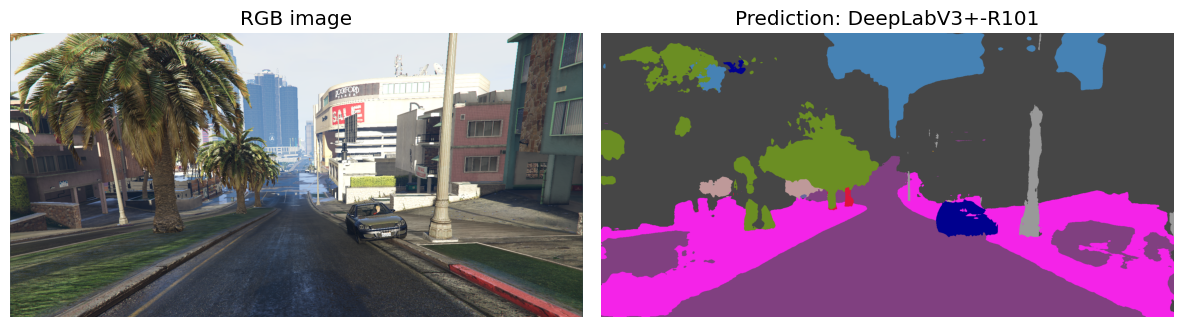

In [7]:
# ---------
# Preview in notebook
# ---------
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(rgb_np)
ax1.set_title("RGB image")
ax1.axis("off")

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(seg_rgb)
ax2.set_title(f"Prediction: {adapter.name}")
ax2.axis("off")

fig.tight_layout()
plt.show()
plt.close(fig)


In [8]:
# ---------
# Export outputs
# ---------
stem = Path(image_path).stem
model_slug = adapter.name.replace(" ", "_").replace("/", "_").replace("+", "plus")

save_mask_png = os.path.join(SAVE_DIR, f"{stem}__{model_slug}__segmentation.png")
save_preview_pdf = os.path.join(SAVE_DIR, f"{stem}__{model_slug}__preview.pdf")
save_preview_png = os.path.join(SAVE_DIR, f"{stem}__{model_slug}__preview.png")

Image.fromarray(seg_rgb).save(save_mask_png)

preview_figsize = tuple(EXPORT_CFG.get("preview_figsize", [12, 5]))
preview_dpi = int(EXPORT_CFG.get("preview_dpi", 200))
save_png_too = bool(EXPORT_CFG.get("save_png_too", True))

fig = plt.figure(figsize=preview_figsize)
ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(rgb_np)
ax1.set_title("RGB image")
ax1.axis("off")

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(seg_rgb)
ax2.set_title(f"Prediction: {adapter.name}")
ax2.axis("off")

fig.tight_layout()
fig.savefig(save_preview_pdf, bbox_inches="tight")
if save_png_too:
    fig.savefig(save_preview_png, dpi=preview_dpi, bbox_inches="tight")
plt.close(fig)

if EXPORT_CFG.get("save_raw_prediction_npy", True):
    np.save(os.path.join(SAVE_DIR, f"{stem}__{model_slug}__prediction.npy"), pred_np)
if EXPORT_CFG.get("save_confidence_npy", False):
    np.save(os.path.join(SAVE_DIR, f"{stem}__{model_slug}__confidence.npy"), conf_np)

summary = {
    "image_path": image_path,
    "model_name": adapter.name,
    "model_key": MODEL_CFG.get("key"),
    "model_type": MODEL_CFG.get("type"),
    "model_id": MODEL_CFG.get("model_id"),
    "checkpoint_path": MODEL_CFG.get("checkpoint_path"),
    "input_norm": MODEL_CFG.get("input_norm"),
    "device": str(DEVICE),
    "prediction_shape": list(pred_np.shape),
    "confidence_mean": float(conf_np.mean()),
    "outputs": {
        "segmentation_png": save_mask_png,
        "preview_pdf": save_preview_pdf,
        "preview_png": save_preview_png if save_png_too else None,
    }
}

with open(os.path.join(SAVE_DIR, f"{stem}__{model_slug}__summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

summary


{'image_path': '/home/ace/Downloads/Dataset/Day/878_Day_EXTRASUNNY.png',
 'model_name': 'DeepLabV3+-R101',
 'model_key': 'deeplabv3plus_r101_local',
 'model_type': 'deeplabv3plus_r101',
 'model_id': None,
 'checkpoint_path': '/home/ace/Downloads/models_weights/best_deeplabv3plus_resnet101_cityscapes_os16.pth',
 'input_norm': 'none',
 'device': 'cuda',
 'prediction_shape': [950, 1916],
 'confidence_mean': 0.9092100858688354,
 'outputs': {'segmentation_png': './single_segmentation_outputs_deeplab/878_Day_EXTRASUNNY__DeepLabV3plus-R101__segmentation.png',
  'preview_pdf': './single_segmentation_outputs_deeplab/878_Day_EXTRASUNNY__DeepLabV3plus-R101__preview.pdf',
  'preview_png': './single_segmentation_outputs_deeplab/878_Day_EXTRASUNNY__DeepLabV3plus-R101__preview.png'}}